# Notebook for testing python fista implementation

In [3]:
import sys
import pywt
import time
import helpers

sys.path.insert(1, '../fista-python/')

import fista
from fista import Filter2D
import matplotlib
import matplotlib.pyplot as plt
import numpy

wavelets=[pywt.Wavelet('db1'), pywt.Wavelet('db2'), pywt.Wavelet('db3'), pywt.Wavelet('db4'), pywt.Wavelet('db5'), \
         pywt.Wavelet('db6'), pywt.Wavelet('db7'), pywt.Wavelet('db8')]

cmap="turbo"

matplotlib.rcParams['figure.figsize'] = [10, 5]

## Test for normal fista deconvolution

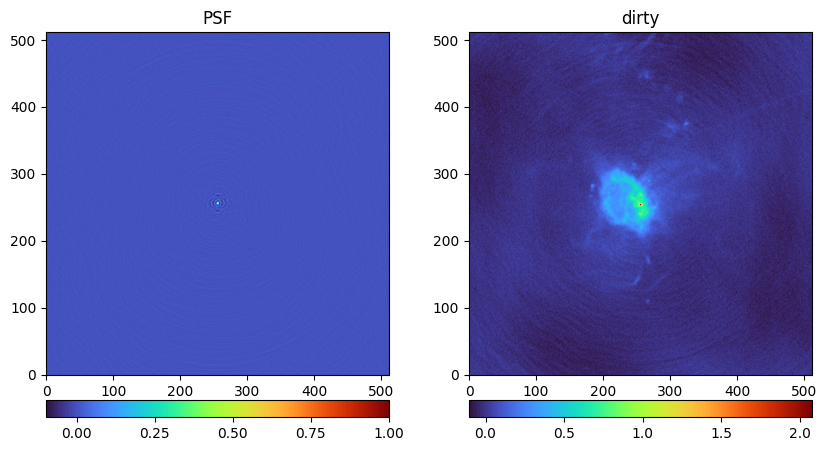

In [2]:
psf = helpers.readFits("../data/SGRA_full_psf.fits")
dirty = helpers.readFits("../data/SGRA_full_dirty.fits")
gt = helpers.readFits("../data/SGRA_full_gt.fits")

helpers.plotNImages([psf, dirty], ["PSF", "dirty"], cmap=cmap)

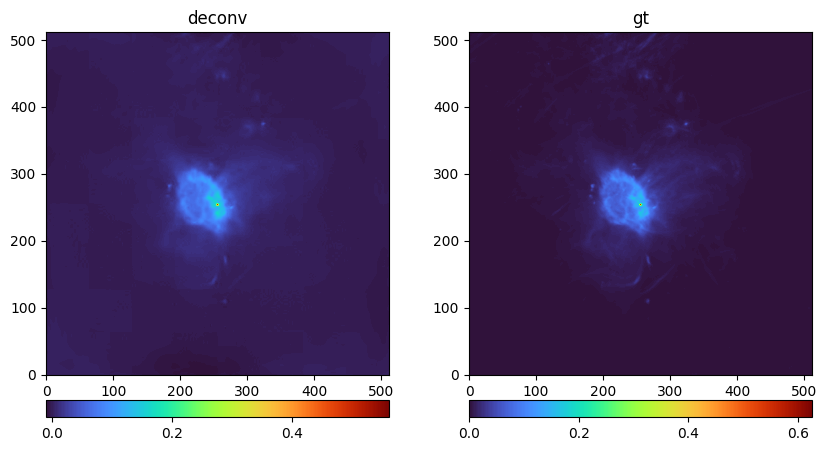

In [14]:
psf_fista = Filter2D(psf)

deconvolved = fista.fista(psf_fista, dirty, 0.002, wavelets, 100, linear_conv=True)
helpers.plotNImages([deconvolved, gt], ["deconv", "gt"], cmap=cmap)

## Multipartition test

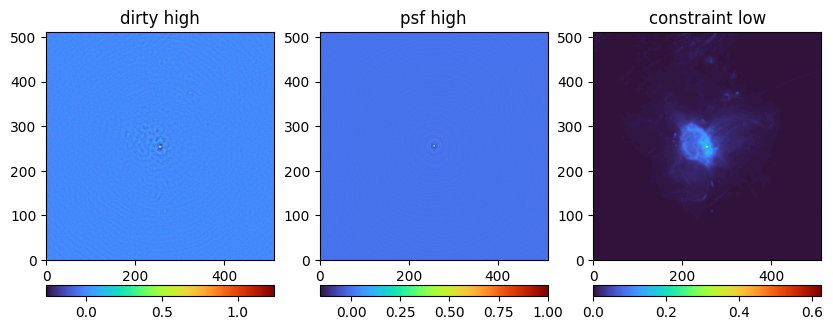

In [16]:
sys.path.insert(1, '../interleaved_parallelization_prototype/')

from ip_helpers import create_nfilters

dataset = "SGRA"
dirty_high = helpers.readFits("../data/SGRA_high34_dirty.fits")
psf_high = helpers.readFits("../data/SGRA_high34_psf.fits")

helpers.plotNImages([dirty_high, psf_high, gt], ["dirty high", "psf high", "constraint low"], cmap=cmap)


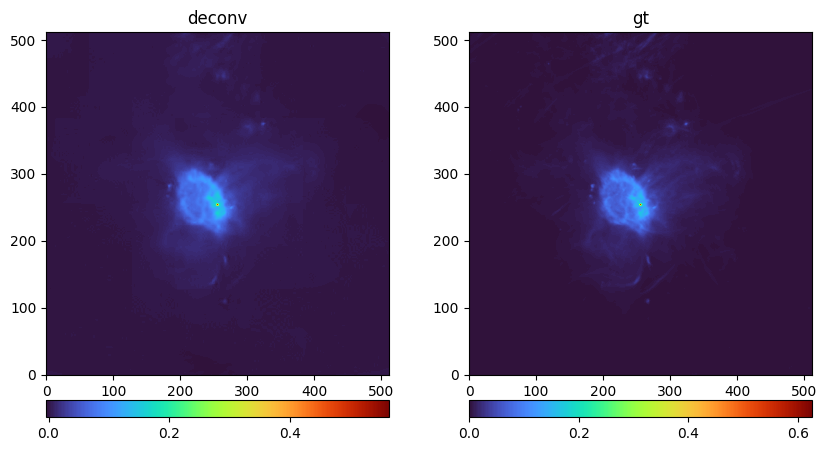

In [17]:
psf_fista_high = Filter2D(psf_high)
constraints = [gt, dirty_high]

sigma2s = []

for c in constraints:
    sigma2s.append(numpy.mean(helpers.compute_windowed_var(c, 5)))
    
fs, _ = create_nfilters(psf_high.shape[0], 1, [35], sigma2s)

filters = []
for f in fs:
    filters.append(Filter2D(f))

deconvolved_mp = fista.fista(psf_fista_high, dirty_high, 0.002, wavelets, 100, partition=1,\
                          parallelize_wavelets=False, filters=filters, constraint_images=constraints, linear_conv=True)

helpers.plotNImages([deconvolved_mp, gt], ["deconv", "gt"], cmap=cmap)

## Speed comparison to Julia implementation

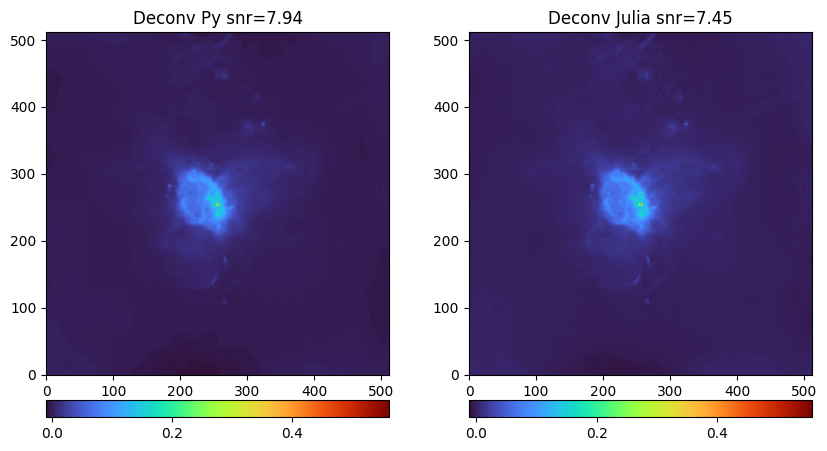

Time python: 19.880939722061157
Time julia: 40.59420990943909


In [18]:
start_py = time.time()
deconv_py = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=False, linear_conv=True)
end_py=time.time()

psf_name = "tmp_psf.fits"
dirty_name = "tmp_dirty.fits"
out_name = "tmp_out.fits"

helpers.write_nparr_to_fits(psf, psf_name)
helpers.write_nparr_to_fits(dirty, dirty_name)

import os

start_julia = time.time()
os.system("julia ../interleaved_parallelization_prototype/julia/make_fullres_mp.jl 0.002 " + psf_name + \
              " " + dirty_name + " 0 100 " + out_name)
end_julia = time.time()

deconv_julia = helpers.readFits(out_name)

snr_py = helpers.compute_snr(gt, deconv_py)
snr_julia = helpers.compute_snr(gt, deconv_julia)

helpers.plotNImages([deconv_py, deconv_julia], ["Deconv Py snr=" + "{:0.2f}".format(snr_py), "Deconv Julia snr=" + "{:0.2f}".format(snr_julia)], cmap=cmap)
print("Time python: " + str(end_py - start_py))
print("Time julia: " + str(end_julia - start_julia))

## Serial vs Parallel implementation

Times, serial-parallel: 11.102750778198242 : 31.725391387939453


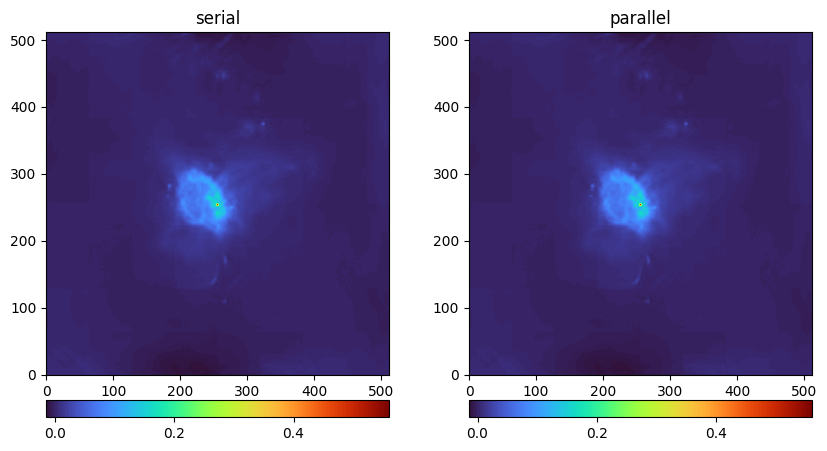

In [7]:
psf_fista = Filter2D(psf)

start_serial = time.time()
deconv_serial = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=False)
end_serial=time.time()

start_parallel = time.time()
deconv_parallel = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=True)
end_parallel=time.time()

print("Times, serial-parallel: " + str(end_serial-start_serial) + " : " + str(end_parallel-start_parallel))

helpers.plotNImages([deconv_serial, deconv_parallel], ["serial", "parallel"], cmap=cmap)

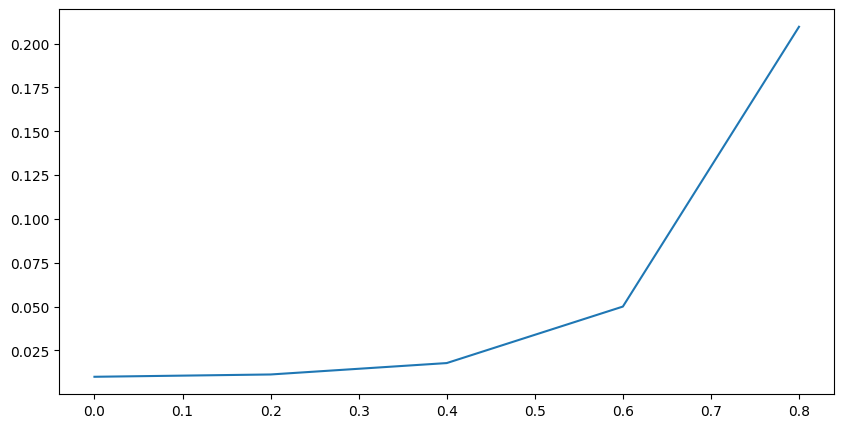

In [24]:
start = 0.01
end = 1

xs = [0, 0.2, 0.4, 0.6, 0.8]
k = 8
ys = [start + (end - start) * ((numpy.exp(k * x) - 1) / (numpy.exp(k) - 1)) for x in xs]

plt.plot(xs, ys)